In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns

In [20]:
# data_tvbs改 = pd.read_csv('tvbs_蘇花改_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #380
# data_自由改 = pd.read_csv('自由_蘇花改_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #2598
data_ettoday公路 = pd.read_csv('ettoday_蘇花公路_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #1702
data_ettoday改 = pd.read_csv('ettoday_蘇花改_full.csv').drop(columns='Link').dropna().reset_index(drop=True) #1050
data_ettoday公路['PublishTime'] = pd.to_datetime(data_ettoday公路['PublishTime'], errors='coerce')
data_ettoday公路['PublishTime'] = data_ettoday公路['PublishTime'].dt.strftime('%Y/%m/%d %H:%M')
data_ettoday改['PublishTime'] = pd.to_datetime(data_ettoday改['PublishTime'], errors='coerce')
data_ettoday改['PublishTime'] = data_ettoday改['PublishTime'].dt.strftime('%Y/%m/%d %H:%M')
# data = pd.concat([data_tvbs公路, data_tvbs改, data_自由公路, data_自由改, data_ettoday公路, data_ettoday改], ignore_index=True)
data = pd.concat([data_ettoday公路, data_ettoday改], ignore_index=True)

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2703 entries, 0 to 2702
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Title        2703 non-null   object
 1   Context      2703 non-null   object
 2   PublishTime  2655 non-null   object
dtypes: object(3)
memory usage: 63.5+ KB


In [21]:
data['Context'].duplicated().sum()

243

In [22]:
data = data[~data['Context'].duplicated()].reset_index(drop=True)
data = data.dropna(subset=['PublishTime'])

In [23]:
data.head(10)

,Title,Context,PublishTime
0,花蓮台9線車禍！雙載機車自撞「跌落邊坡20m」 消防救援畫面曝,蘇花公路台9線161公里處，今（22）日早上發生交通事故，雙載機車不明原因自撞，摔落邊坡約2...,2025/06/22 10:33
1,花公路落石釀車損！1輛引擎蓋凹陷、1輛左前輪爆胎,蘇花公路宜蘭南澳鄉台九線116公里處發生落石擊中車輛事故。15日下午13時許，一輛轎車引擎蓋...,2025/06/16 14:57
2,花蓮對面是阿根廷福爾摩沙省 他們以藝術紀錄地震傷痕,花蓮地震寫生團像一支自動發起的遠征隊，由一群在地年輕藝術家組成，在2024年4月3日的花蓮震...,2025/06/09 11:47
3,11萬噸殘骸的土資場沒錢處理 脆弱交通讓花蓮旅遊雪上加霜,東華大學化學實驗室在震後因化學物品翻覆起火，燒了整整22個小時。寫生團進入實驗室內部時，現場...,2025/06/09 11:46
4,蘇花公路和仁路段管制閘門施工 6月9至13日機動交管,台九線蘇花公路和仁路段將進行管制閘門施工，自6月9日至6月13日每日上午8時至下午5時，實施...,2025/06/05 14:07
5,快訊／豪雨、土石流強襲花蓮縣 秀林鄉和平村明上午停班停課,受到20日豪大雨影響，花蓮多地傳出淹水、土石流等災情。對此，花蓮縣秀林鄉公所18日深夜緊急發...,2025/05/20 22:34
6,花蓮豪雨「土石流轟炸道路」恐怖畫面曝光 民眾躲隧道內尖叫,受豪雨影響，台9線蘇花公路164k處發生土石流，目前雙向交通中斷受阻，交通部已下令啟動海陸空...,2025/05/20 20:46
7,花蓮爆雨「蘇花鐵公路雙斷」 交長下令啟動海陸空跨運具聯防,今(20)日16時起花蓮地區因豪雨不斷，蘇花公路台9線162.9公里處落石瀑、164.4公里...,2025/05/20 20:24
8,蘇花路廊土石流阻斷「80車受困」 今晚9時搶通,台9線蘇花路廊和仁到崇德路段上邊坡土石流狂瀉，導致阻斷無法通行，南下72部、北上7部共80輛...,2025/05/20 19:12
9,蘇花公路又中斷！土石流狂瀉 和仁到崇德段只出不進,大雨不斷，台9線蘇花公路164k處發生土石流，目前雙向交通中斷受阻。公路局宣布，今下午4時半...,2025/05/20 16:53


In [24]:
data['PublishTime'] = pd.to_datetime(data['PublishTime'], format='%Y/%m/%d %H:%M', errors='coerce')

In [25]:
data['PublishYear'] = data['PublishTime'].dt.to_period('Y').astype(str)

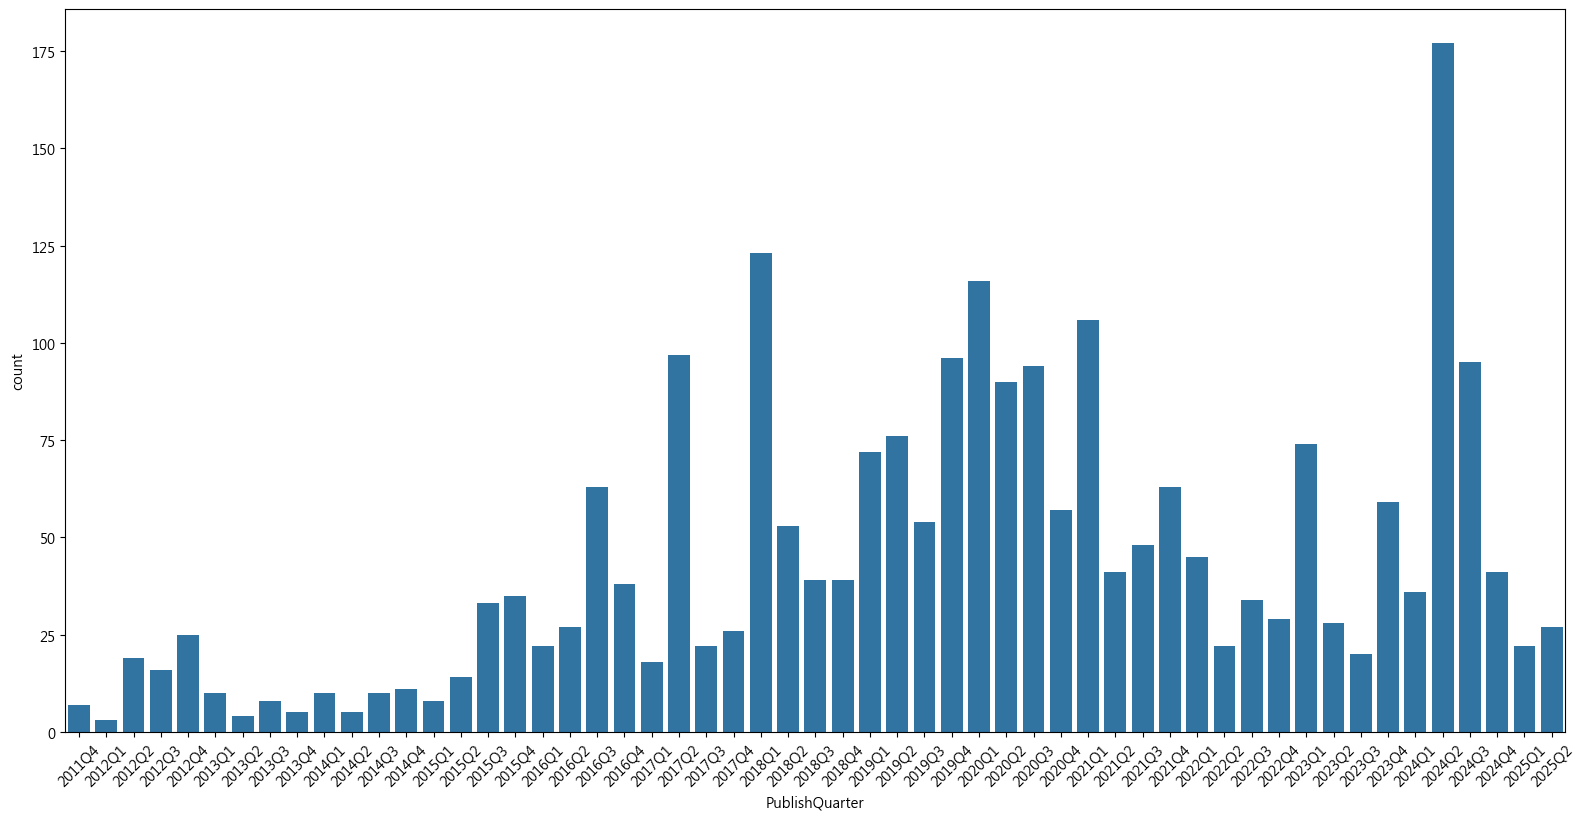

In [26]:
data['PublishQuarter'] = data['PublishTime'].dt.to_period('Q').astype(str)
plt.figure(figsize=(16, 8))
sns.countplot(data=data, x='PublishQuarter', order=sorted(data['PublishQuarter']))
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [27]:
data = data[(pd.to_datetime(data['PublishTime']) >= pd.Timestamp('2015-01-01')) 
            & (pd.to_datetime(data['PublishTime']) <= pd.Timestamp('2024-12-31'))].reset_index(drop=True)


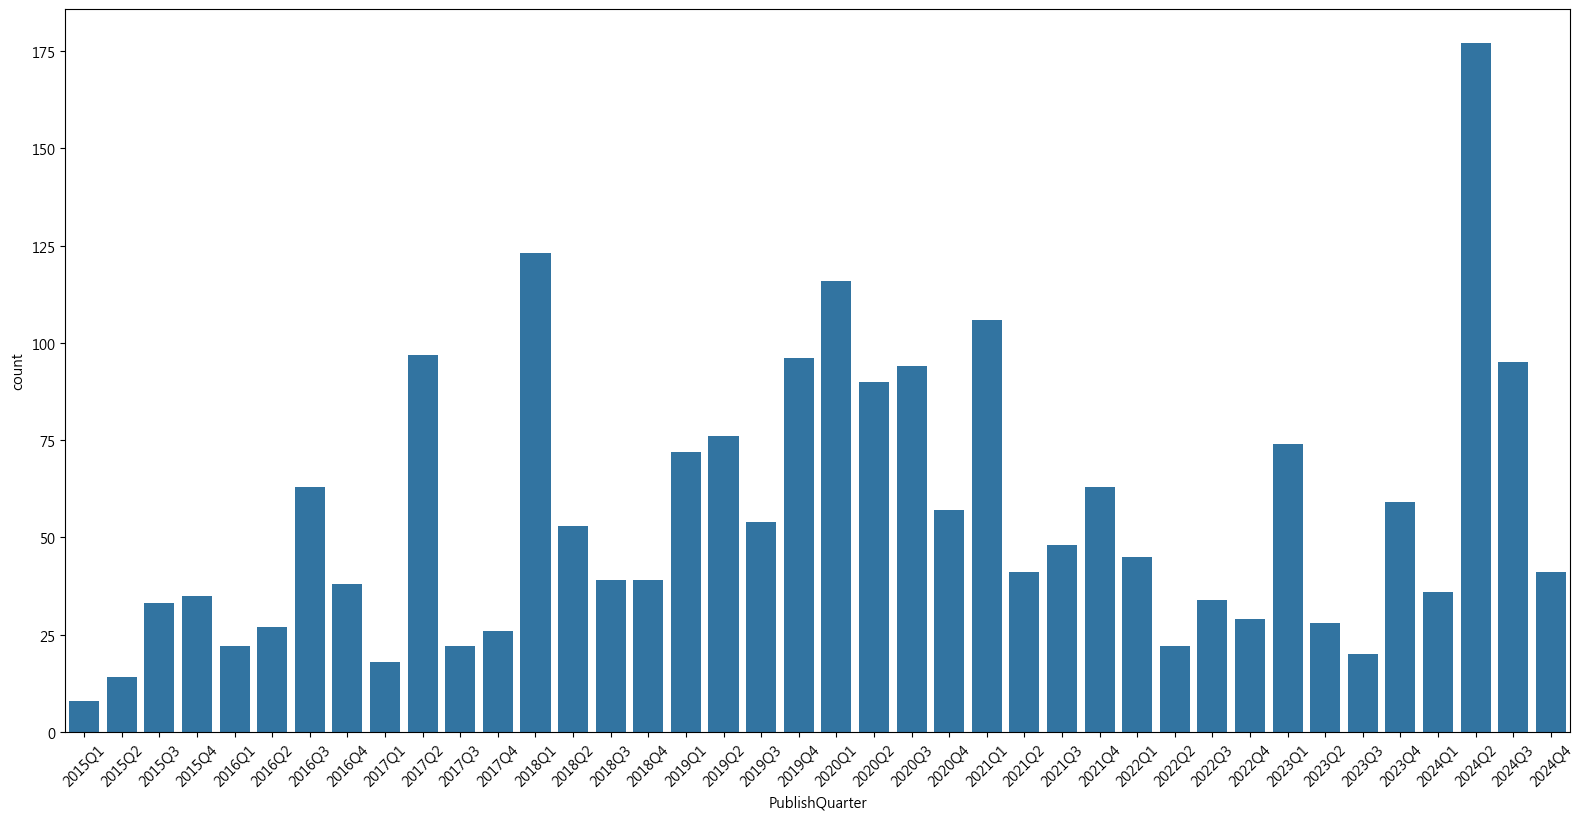

In [28]:
plt.figure(figsize=(16, 8))
sns.countplot(data=data, x='PublishQuarter', order=sorted(data['PublishQuarter']))
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [29]:
text_all = '\n'.join(data['Context'].dropna())

In [30]:
import jieba, re, string

In [31]:
fullwidth_punctuation = "，。！？：；「」『』（）〔〕【】《》—…～‧、．／ﾟ"
all_punct = string.punctuation + fullwidth_punctuation

def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()

    # 刪除車牌號碼（如 KAA-0853, 123ABC 等格式）
    text = re.sub(r'(?:[A-Z]{1,3}-?\d{3,4}|\d{3,4}-?[A-Z]{1,3})', '', text, flags=re.IGNORECASE)

    # text = text.translate(str.maketrans('', '', all_punct)) # 刪標點
    text = re.sub(r'\[.*?\]', '', text) # 刪 [] 內內容
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # 刪網址
    text = re.sub(r'<.*?>', '', text) # 刪 HTML tag

    # 刪除換行、數字、空白
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text
data["Cleaned_Context"] = data["Context"].apply(clean_text)
data["Cleaned_Context"].tolist()

['年即將步入尾聲，《ettoday新聞雲》回顧過去一年，整理出台灣 大熱門旅遊話題，包括地震對花蓮觀光影響、新的對台免簽政策、全新亮點飯店與航點開航等均上榜，來看看哪些話題讓你最印象深刻。 .年代旅遊農曆春節丟包上百旅客在富國島 在農曆春節期間，年代旅遊遭爆丟包上百名旅客在富國島，不僅被丟包，還要再自費 美金（約新台幣 萬 元）才能繼續行程，部分旅客更被迫提早結束行程，另外買機票返回台灣，掀起社會熱議。 後續經交通部觀光署查處，發現該公司財務業務異常，對外積欠債務逾千萬餘元，負責人林大鈞也直言沒錢賠償旅客。目前年代旅遊已被勒令停業、林大鈞 年內禁止經營旅行社，而品保協會也啟動保險理賠機制，但由於人數龐大，旅客想拿回賠償，恐還要等上一段時間。 . 地震重創花蓮觀光 月 日當天早上 點 分左右，花蓮發生規模 . 大地震，全台都劇烈搖晃，花蓮也發生多棟建築倒塌、橋樑毀損，中橫公路及蘇花公路、蘇花改均受影響而封閉，台鐵、高鐵、捷運也一度停駛，太魯閣國家公園內也因此次地震導致山體崩落、多條步道暫時封閉，更一度有多名遊客受困山中。 此次地震對花蓮觀光影響至今尚未恢復，已有十多家旅館業者選擇暫停或結束營業，或提前開始重新整建階段，加上後續數個颱風再次重創當地交通，雖然觀光署祭出國旅補助，但仍影響消費者旅遊信心，當地旅宿業者就預估從地震後至今，損失已數十億。 .新飯店遍地開花！國際級飯店紛紛進駐台灣 看好台灣市場發展潛力，國際級飯店紛紛進駐台灣，從高端與精緻商務的台中勤美洲際酒店、高雄日航酒店開幕，嘉義福容voco為全台首間該品牌酒店進駐台灣；還有時尚設計的「台北大安伊普索凱悅尚選酒店」，到日系商務旅宿「相鐵grand fresa台北西門」，都提供旅人更多住宿選擇。 而台灣各大飯店業者也紛紛以拓點或改裝搶市，以不同品牌定位和價格，搶攻不同客群市場。奢華旅宿如甫於 月開幕的日月潭「漢來日月行館」，不但再次挑戰台灣飯店房價極限，也為日月潭地區提供全新奢華旅宿選擇與體驗；礁溪老爺酒店選擇暫停 個月營業時間進行館內大改裝，以新氣象迎賓。 .演唱會經濟、熱門ip接力現身 高雄真正發大財 根據多家國內外大型旅遊業者與電商平台分析，節慶與特殊活動舉辦已成為吸引旅客到當地旅遊的主要誘因，帶動觀光熱潮與經濟發展，這項分析從高雄可看到實證。 近年如blackpink、新好男孩、coldplay、紅髮

In [32]:
synonym_dict = {'花蓮縣':'花蓮', '花蓮市':'花蓮', '舊蘇花':'蘇花公路', '蘇花':'蘇花公路', '蘇花公路':'蘇花公路', '蘇花路廊':'蘇花路廊',
                '蘇花改':'蘇花改', '蘇花高':'蘇花高', '蘇花安':'蘇花安', '台九':'台九線', '台九丁線':'台九線'}
with open('停用詞-繁體中文.txt', encoding='utf-8') as f:
    stopwords = set(line.strip() for line in f)

### CKIPtagger

In [33]:
# from ckiptagger import WS
# ws = WS(r"C:\Users\USER\Documents\CKIP")

# # text = ["蘇花改是蘇花公路的重要替代路段"]
# # ws_results = ws(text)
# # print(ws_results[0])

# texts = data['Cleaned_Context'].fillna('').tolist()
# ws_results = ws(texts)

# data['CKIP_Tokens'] = ws_results

# def normalize_ckip_tokens(tokens, synonym_dict, stopwords):
#     normalize_tokens = [synonym_dict.get(token, token) for token in tokens]
#     filter_tokens = [token for token in normalize_tokens if token not in stopwords and len(token)>1 and token.isalpha()]
#     return filter_tokens

# data['CKIP_Tokens'] = data['CKIP_Tokens'].apply(lambda x: normalize_ckip_tokens(x, synonym_dict, stopwords))


### CKIPtransformer

In [34]:
from ckip_transformers.nlp import CkipWordSegmenter
ws_driver  = CkipWordSegmenter(model="bert-base")

texts = data['Cleaned_Context'].fillna('').tolist()
ws_results = ws_driver(texts)

data['CKIP_Tokens'] = ws_results

def normalize_ckip_tokens(tokens, synonym_dict, stopwords):
    normalize_tokens = [synonym_dict.get(token, token) for token in tokens]
    filter_tokens = [token for token in normalize_tokens if token not in stopwords and len(token)>1 and token.isalpha()]
    return filter_tokens

custom_stopwords = {'http', 'https', 'gov', 'www', 'com', 'net', 'tw', 'thbgovtw', 'httpswwwgaeavillacomzhtwintlyogaday', 'phpabout',
                    'groupbuy', 'httpswwwrail', 'way', 'govtwtratipwebtipblocklist', 'httptourhualienhl', 'httpswww', 'comhltour', 'httpswwwlien', 'comtw',
                    'httpsfarmersbuycasorgtw', 'httpswwwafasaletw', 'httpsgofishatriorgtwindexpage', 'httpsfishgoatriorgtw', 'of', 'reshatriorgtw', 'thb',
                    'govtw', 'wgvm', 'comt', 'httpswebkamalancomtwweborderterm', 'httpscampaigncwcomtwsmiletaiw', 'andtop', 'httpsbaoming', 'httpsbaoming',
                    'httpswebkamal', 'comtwwe', 'bor', 'derterm', 'cms', 'httpsgoogl', 'httpswwwfacebookcomclericice', ''}
stopwords.update(custom_stopwords)

data['CKIP_Tokens'] = data['CKIP_Tokens'].apply(lambda x: normalize_ckip_tokens(x, synonym_dict, stopwords))

Inference: 100%|██████████| 16/16 [28:25<00:00, 106.57s/it]


In [35]:
del ws_driver

### Jieba

In [36]:
# extra_words = ['新聞雲', '清水橋', '強降雨', '降雨', '土石流', '颱風', '重創']

# for word in set(list(synonym_dict.keys()) + list(synonym_dict.values()) + extra_words):
#     jieba.add_word(word)

# def tokenize(text, synonym_dict, stopwords):
#     if pd.isna(text):
#         return []
#     tokens = list(jieba.cut(text))
#     normalize_tokens = [synonym_dict.get(token, token) for token in tokens]
#     filter_tokens = [token for token in normalize_tokens if token not in stopwords and len(token)>1 and token.isalpha()]
#     return filter_tokens

# data['Tokens'] = data['Cleaned_Context'].apply(lambda x: tokenize(x, synonym_dict, stopwords))

# # print(list(jieba.cut("蘇花改是蘇花公路的重要替代路段")))


In [37]:
data['CKIP_Tokens'].head(5)

0    [步入, 尾聲, ettoday, 新聞, 回顧, 過去, 整理出, 台灣, 熱門, 旅遊,...
1    [集合, 旅行, 朋友, 親子, 旅行, 來到, 宜蘭, 旅遊, 行程, 羅東, 夜市, 山...
2    [蘇花公路, 清水橋, 臨時, 便橋, 進行, 拆除, 施工, 施工, 期間, 進行, 單線...
3    [交通部, 前部長, 李孟諺, 婚外情, 請辭, 陳世凱, 臨危受命, 接棒, 質疑, 交通...
4    [美好, 生活, 旅行, 美食, 旅遊, 親子, 生活, 日記, 位於, 蘇花公路, 南方澳...
Name: CKIP_Tokens, dtype: object

### 詞量 前30

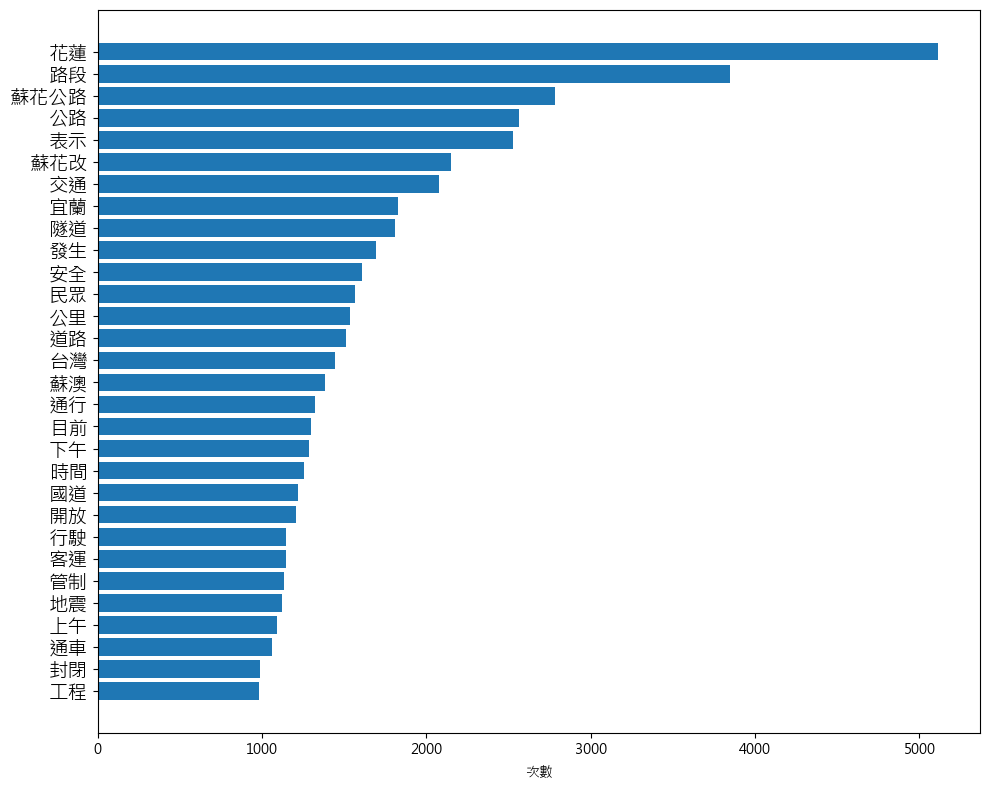

In [38]:
from collections import Counter
all_tokens = [token for tokens in data['CKIP_Tokens'] for token in tokens]
word_freq = Counter(all_tokens)
top_30_words = word_freq.most_common(30)
top_30_df = pd.DataFrame(top_30_words, columns=['Token', 'Frequency'])

plt.figure(figsize=(10, 8))
plt.barh(top_30_df['Token'][::-1], top_30_df['Frequency'][::-1])
plt.xlabel('次數')
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

### 詞頻

In [39]:
from sklearn.feature_extraction.text import CountVectorizer

data['Joined_Tokens'] = data['CKIP_Tokens'].apply(lambda tokens: ' '.join(tokens))
vectorizer = CountVectorizer()
X_tf = vectorizer.fit_transform(data['Joined_Tokens'])

term_freq_matrix = pd.DataFrame(X_tf.toarray(), columns=vectorizer.get_feature_names_out())
term_freq_matrix.index = data.index
term_freq_matrix.head(5)

,aaron,abs,ac,acc,action,adas,aed,afc,ag,again,...,龜裂,龜速,龜速車,龜首,車站,路段,路線,ｄａｋａ,ｑ彈,ｓｕｐ
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
# term_freq_matrix.to_csv('term_freq_matrix.csv', encoding='utf-8-sig', index=False)

### 詞tf-idf

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
Tfidf_vectorizer = TfidfVectorizer()
X_tfidf = Tfidf_vectorizer.fit_transform(data['Joined_Tokens'])
term_freq_idf_matrix = pd.DataFrame(X_tfidf.toarray(), columns=Tfidf_vectorizer.get_feature_names_out())

In [42]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel

In [43]:
dict = Dictionary(data['CKIP_Tokens'])
dict.filter_extremes(no_below=20, no_above=0.8)
corpus = [dict.doc2bow(tokens) for tokens in data['CKIP_Tokens']]

gensim_lda = LdaModel(corpus=corpus, id2word=dict, num_topics=5, random_state=42, eta=0.01)

doc_topics = [gensim_lda.get_document_topics(doc_bow, minimum_probability=0.0) for doc_bow in corpus]
main_topic = [max(topics, key=lambda x: x[1])[0] for topics in doc_topics]

data['Topic'] = [ t+1 for t in main_topic]

In [44]:
for i in range(gensim_lda.num_topics):
    print(f'主題{i}')
    print(gensim_lda.print_topic(i, topn=20))
    print('-'*50)

主題0
0.043*"花蓮" + 0.011*"工程" + 0.011*"蘇花改" + 0.009*"表示" + 0.009*"隧道" + 0.006*"通車" + 0.006*"交通" + 0.006*"發生" + 0.005*"政府" + 0.005*"蘇花公路" + 0.005*"傅崐萁" + 0.005*"計畫" + 0.005*"民眾" + 0.005*"台灣" + 0.005*"目前" + 0.004*"中央" + 0.004*"地方" + 0.004*"地震" + 0.004*"觀光" + 0.004*"施工"
--------------------------------------------------
主題1
0.021*"路段" + 0.012*"公路" + 0.012*"蘇花改" + 0.011*"行車" + 0.011*"安全" + 0.009*"蘇澳" + 0.009*"交通" + 0.008*"公里" + 0.007*"蘇花公路" + 0.007*"通車" + 0.007*"道路" + 0.006*"北上" + 0.006*"公路總局" + 0.006*"總局" + 0.006*"路況" + 0.006*"用路人" + 0.006*"花蓮" + 0.006*"管制" + 0.005*"隧道" + 0.005*"通行"
--------------------------------------------------
主題2
0.027*"宜蘭" + 0.011*"交通" + 0.010*"國道" + 0.010*"表示" + 0.008*"系統" + 0.007*"蘇花改" + 0.007*"優惠" + 0.007*"交通部" + 0.007*"客運" + 0.006*"連假" + 0.006*"民眾" + 0.006*"蘇澳" + 0.006*"路段" + 0.006*"高鐵" + 0.005*"時間" + 0.005*"林佳龍" + 0.005*"春節" + 0.005*"羅東" + 0.005*"轉運站" + 0.005*"規劃"
--------------------------------------------------
主題3
0.014*"花蓮" + 0.012*"台灣" + 0.010*"建設" + 0.00

In [45]:
gensim_lda_vectors = []
for doc_bow in corpus:
    topic_probs = gensim_lda.get_document_topics(doc_bow, minimum_probability=0.0)
    topic_vector = [prob for _, prob in topic_probs]
    gensim_lda_vectors.append(topic_vector)

gensim_lda_vectors = np.array(gensim_lda_vectors)

<Axes: xlabel='x', ylabel='y'>

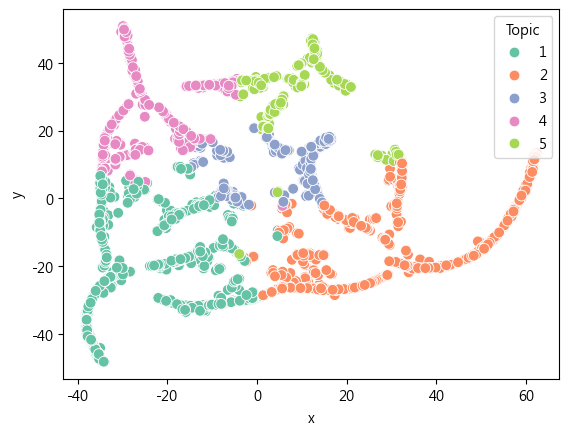

In [46]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
gensim_lda_tsne = tsne.fit_transform(gensim_lda_vectors)
gensim_lda_tsne_df = pd.DataFrame(gensim_lda_tsne, columns=['x', 'y'])
gensim_lda_tsne_df['Topic'] = data['Topic']

sns.scatterplot(data=gensim_lda_tsne_df, x='x', y='y', hue='Topic', palette='Set2', s=60)

In [47]:
from sklearn.decomposition import LatentDirichletAllocation

In [48]:
scikit_lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda_matrix = scikit_lda.fit_transform(X_tf)

data['Topic'] = lda_matrix.argmax(axis=1) +1

In [49]:
topic_word =scikit_lda.components_
topic_word_prob = topic_word/topic_word.sum(axis=1)[:, np.newaxis]
tokens = vectorizer.get_feature_names_out()
phi_df = pd.DataFrame(topic_word_prob, columns=tokens, index=[f'Topic {i+1}' for i in range(scikit_lda.n_components)])

In [50]:
def plot_topic_token_distri(phi_df, top_n):
    for topic in phi_df.index:
        top_words = phi_df.loc[topic].sort_values(ascending=False).head(top_n)
        
        plt.figure(figsize=(8, 6))
        plt.bar(top_words.index, top_words.values)
        plt.title(f'{topic}-Top {top_n} Tokens')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

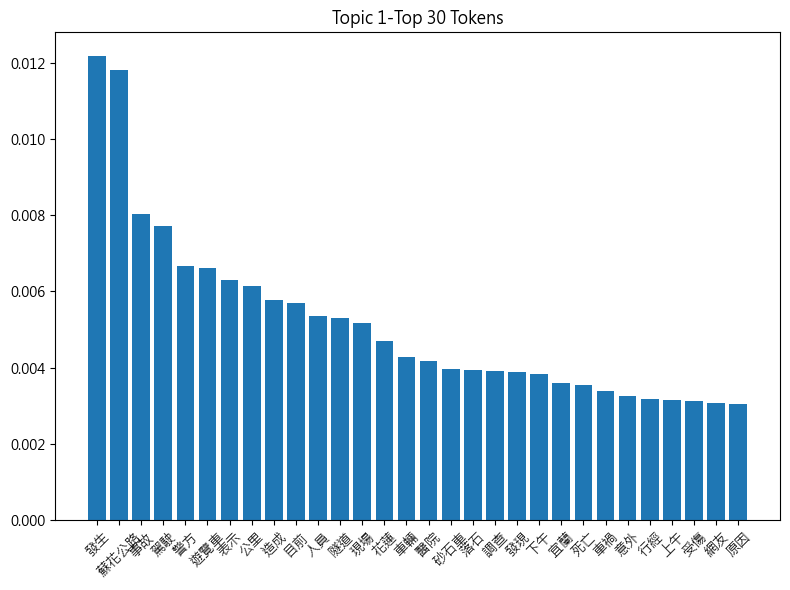

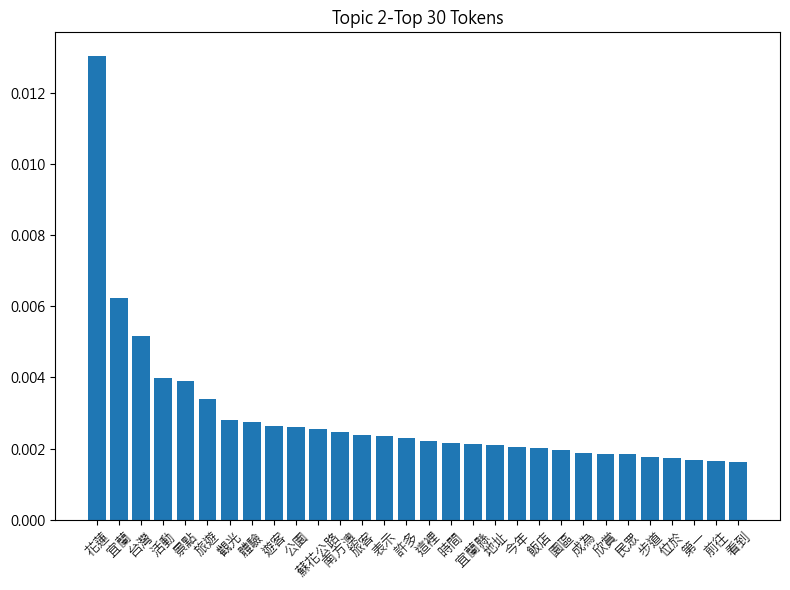

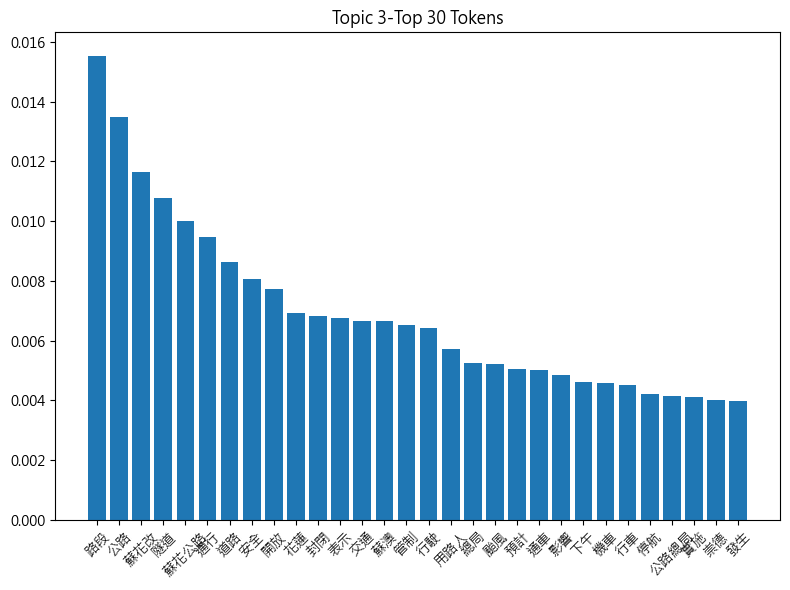

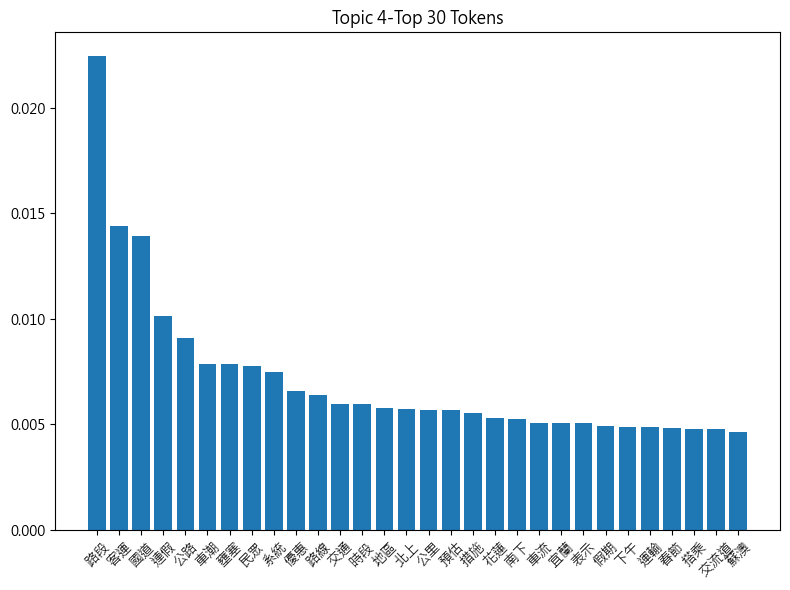

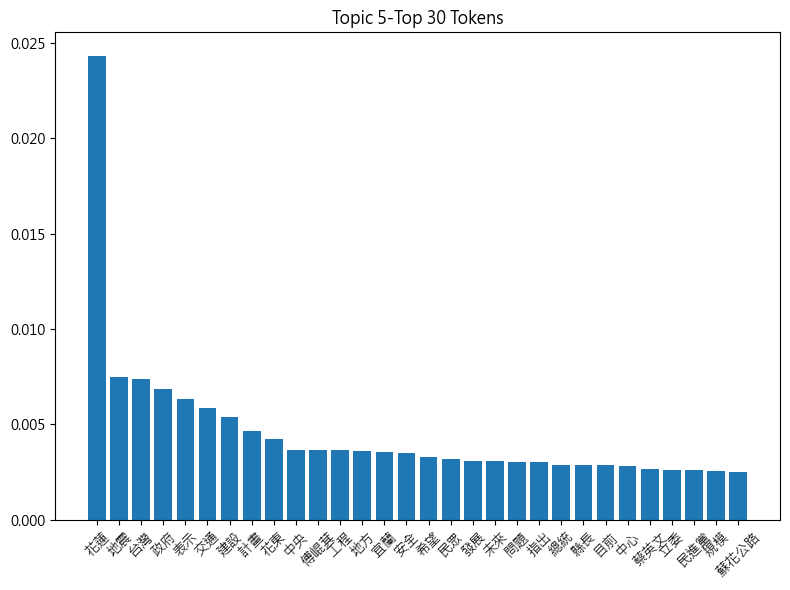

In [51]:
plot_topic_token_distri(phi_df, 30)

In [52]:
def display_topics(model, feature_names, topn=30):
    for index, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-topn-1:-1]]
        print(f"主題 {index+1}: {'、'.join(top_words)}")
display_topics(scikit_lda, vectorizer.get_feature_names_out())

主題 1: 發生、蘇花公路、事故、駕駛、警方、遊覽車、表示、公里、造成、目前、人員、隧道、現場、花蓮、車輛、醫院、砂石車、落石、調查、發現、下午、宜蘭、死亡、車禍、意外、行經、上午、受傷、網友、原因
主題 2: 花蓮、宜蘭、台灣、活動、景點、旅遊、觀光、體驗、遊客、公園、蘇花公路、南方澳、旅客、表示、許多、這裡、時間、宜蘭縣、地址、今年、飯店、園區、成為、欣賞、民眾、步道、位於、第一、前往、看到
主題 3: 路段、公路、蘇花改、隧道、蘇花公路、通行、道路、安全、開放、花蓮、封閉、表示、交通、蘇澳、管制、行駛、用路人、總局、颱風、預計、通車、影響、下午、機車、行車、停航、公路總局、實施、崇德、發生
主題 4: 路段、客運、國道、連假、公路、車潮、壅塞、民眾、系統、優惠、路線、交通、時段、地區、北上、公里、預估、措施、花蓮、南下、車流、宜蘭、表示、假期、下午、運輸、春節、搭乘、交流道、蘇澳
主題 5: 花蓮、地震、台灣、政府、表示、交通、建設、計畫、花東、中央、傅崐萁、工程、地方、宜蘭、安全、希望、民眾、發展、未來、問題、指出、總統、縣長、目前、中心、蔡英文、立委、民進黨、規模、蘇花公路


C:\Users\USER\AppData\Local\Temp\ipykernel_22264\1723535593.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Topic', palette='Set2')


<Axes: xlabel='Topic', ylabel='count'>

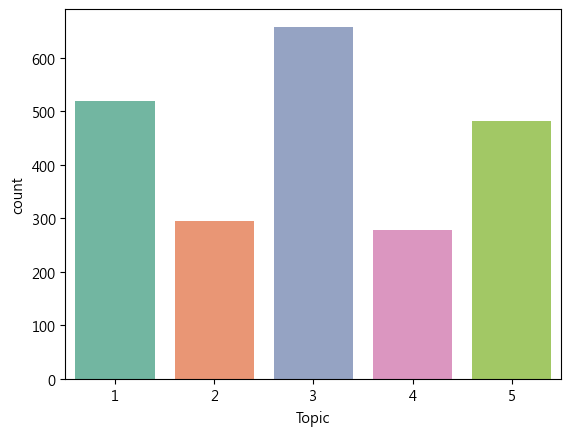

In [53]:
sns.countplot(data=data, x='Topic', palette='Set2')

<Axes: xlabel='x', ylabel='y'>

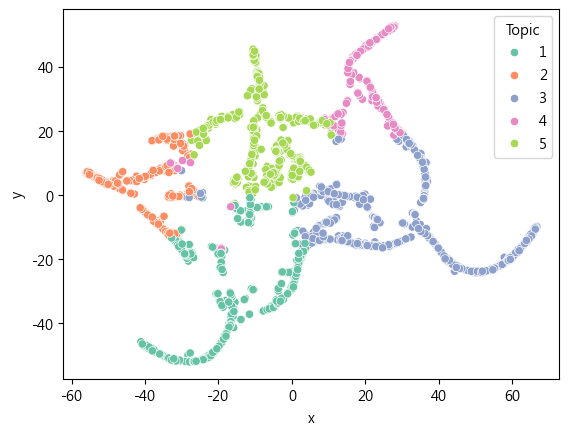

In [54]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
lda_tsne = tsne.fit_transform(lda_matrix)
tsne_df = pd.DataFrame(lda_tsne, columns=['x', 'y'])
tsne_df['Topic'] = data['Topic']

sns.scatterplot(data=tsne_df, x='x', y='y', hue='Topic', palette='Set2')

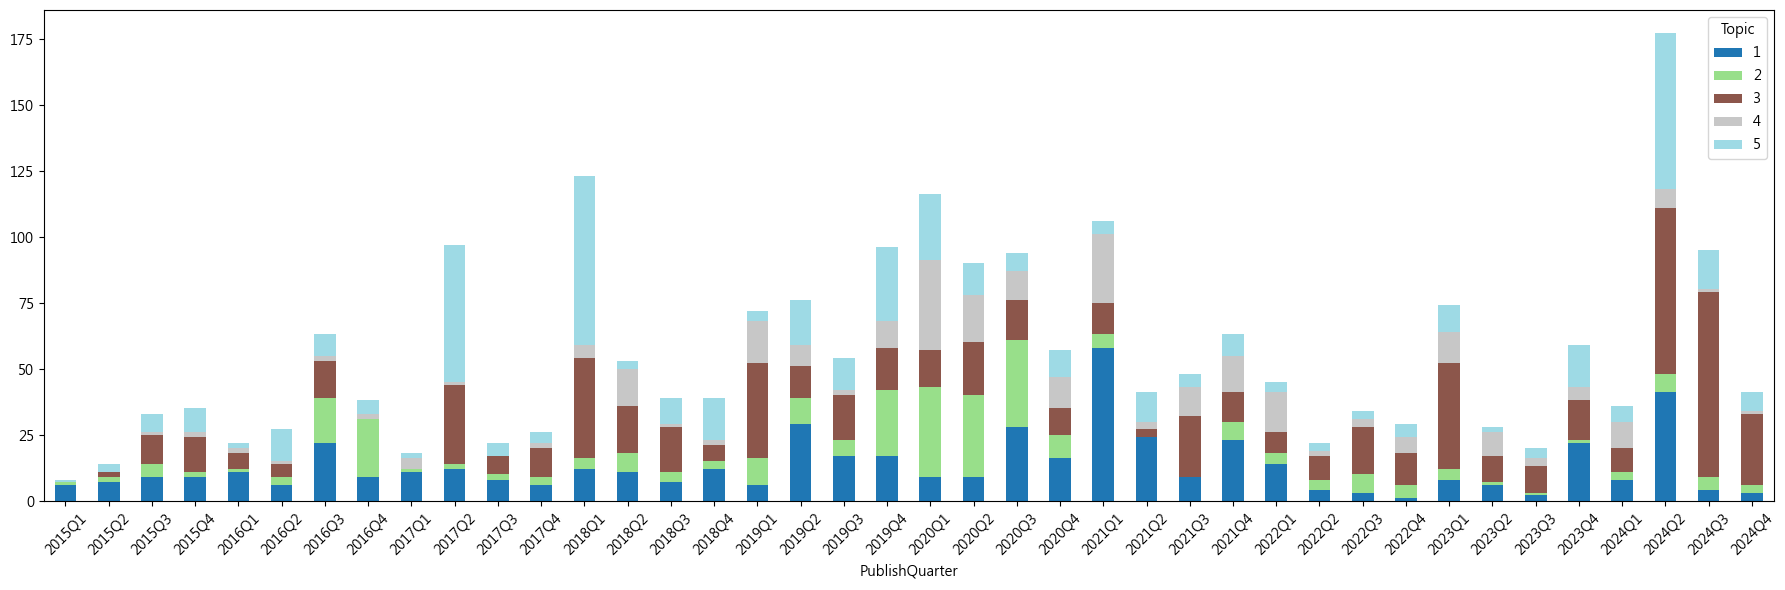

In [55]:
topic_quarter = data.groupby(['PublishQuarter', 'Topic']).size().unstack(fill_value=0)

topic_quarter.plot(kind='bar', stacked=True, colormap='tab20', figsize=(18, 6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

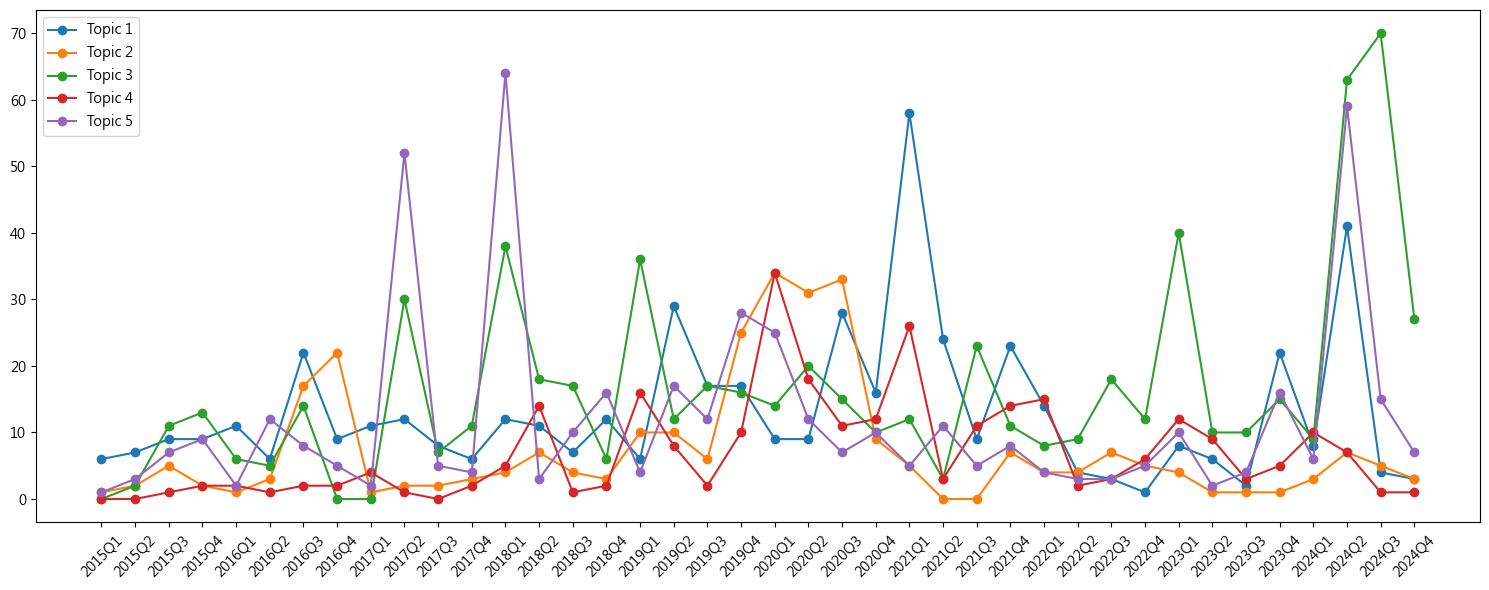

In [56]:
all_quarters = sorted(data['PublishQuarter'].unique())

plt.figure(figsize=(15, 6))
for topic in sorted(data['Topic'].unique()):
    topic_group = data[data['Topic'] == topic].groupby('PublishQuarter').size()
    topic_group = topic_group.reindex(all_quarters, fill_value=0)
    plt.plot(all_quarters, topic_group, marker='o', label=f'Topic {topic}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
n_topics = gensim_lda.num_topics  # 主題數
topic_cols = [f'Topic {i}' for i in range(n_topics)]

df_gensim_lda = pd.DataFrame(gensim_lda_vectors, columns=topic_cols)

# 顯示前幾篇的主題機率
df_gensim_lda.head()


,Topic 0,Topic 1,Topic 2,Topic 3,Topic 4
0,0.581596,0.000379,0.102238,0.181529,0.134259
1,0.000735,0.000731,0.333837,0.479207,0.185490
2,0.001727,0.993115,0.001723,0.001715,0.001721
3,0.036838,0.035205,0.161334,0.766092,0.000531
4,0.435514,0.001756,0.001767,0.239286,0.321677


In [58]:
# df_gensim_lda.head(200).to_csv('prob_gensim_lda_topic_Top200.csv', encoding='utf-8-sig', index=False)

In [59]:
tsne2 = TSNE(n_components=2, random_state=42)
tsne2_results = tsne2.fit_transform(term_freq_matrix)
tsne2_df = pd.DataFrame(tsne2_results, columns=['x', 'y'])
tsne2_df['Topic'] = data['Topic']

<Axes: xlabel='x', ylabel='y'>

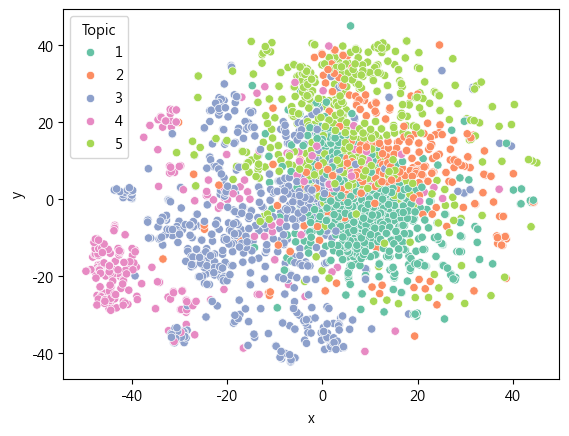

In [60]:
sns.scatterplot(data=tsne2_df, x='x', y='y', hue='Topic', palette='Set2')